# 📊 Analyse des ventes et prédiction du chiffre d'affaires

## Présentation du projet

Ce projet consiste à analyser les données de transactions d'une entreprise afin de comprendre ses performances commerciales et d'utiliser le Machine Learning pour prédire le chiffre d'affaires et identifier les ventes à fort potentiel.

### 🎯 Objectifs

- Explorer et préparer les données de ventes
- Analyser le chiffre d'affaires et les performances commerciales
- Identifier les principaux facteurs associés au chiffre d'affaires
- Construire un modèle de régression pour prédire le CA
- Construire un modèle de classification pour identifier les ventes élevées
- Évaluer et interpréter les performances des modèles

### 🛠️ Technologies utilisées

- SQL
- Python
- Pandas
- Matplotlib
- Scikit-learn
- Machine Learning

## 📁 Données

Le projet repose sur trois fichiers de données :

| Fichier | Description |
|---|---|
| `transactions.csv` | Informations sur les transactions et les quantités vendues |
| `articles.csv` | Informations sur les articles, leur famille et leurs prix |
| `acheteurs.csv` | Informations sur les clients et leurs caractéristiques |

### 📌 Volume des données

- **120 transactions**
- **10 articles**
- **20 acheteurs**

## 1. 🔍 Importation et découverte des données

Dans cette première étape, nous importons les trois fichiers CSV et vérifions leur structure, leurs dimensions et leurs premières observations.

In [1]:
import pandas as pd

acheteurs = pd.read_csv("acheteurs.csv")
articles = pd.read_csv("articles.csv")
transactions = pd.read_csv("transactions.csv")

print("Acheteurs :", acheteurs.shape)
print("Articles :", articles.shape)
print("Transactions :", transactions.shape)

Acheteurs : (20, 6)
Articles : (10, 5)
Transactions : (120, 5)


### 🔎 Première vérification

Les trois fichiers ont été correctement importés.

- `transactions.csv` contient **120 transactions**.
- `articles.csv` contient **10 articles**.
- `acheteurs.csv` contient **20 acheteurs**.

Ces trois sources pourront être reliées grâce aux identifiants `acheteur_id` et `article_id`, afin de construire une table d'analyse complète.

### 🔎 Structure des données

Avant de procéder aux transformations, nous vérifions les colonnes disponibles et les premières observations de chaque table.

In [2]:
print("=== ACHETEURS ===")
display(acheteurs.head())

print("\n=== ARTICLES ===")
display(articles.head())

print("\n=== TRANSACTIONS ===")
display(transactions.head())

=== ACHETEURS ===


,acheteur_id,nom,prenom,ville,date_naissance,date_adhesion
0,1,Diallo,Moussa,Abidjan,1984-08-12,2021-07-09
1,2,Traore,Aminata,Conakry,1982-02-08,2023-08-16
2,3,Coulibaly,Ibrahim,Bamako,1986-07-19,2022-11-18
3,4,Keita,Fatou,Abidjan,1995-05-13,2023-08-16
4,5,Cisse,Mamadou,Abidjan,1986-08-30,2022-07-17



=== ARTICLES ===


,article_id,designation,famille,cout_unitaire,prix_public
0,101,Ordinateur portable,Informatique,420000,650000
1,102,Smartphone,Telephonie,180000,300000
2,103,Tablette,Informatique,150000,250000
3,104,Televiseur LED,Electronique,350000,520000
4,105,Appareil photo,Electronique,280000,430000



=== TRANSACTIONS ===


,transaction_id,date_transaction,acheteur_id,article_id,quantite
0,1105,2023-01-02,5,105,3
1,1034,2023-01-15,17,110,5
2,1007,2023-02-04,9,109,4
3,1046,2023-02-10,16,105,2
4,1035,2023-03-06,2,110,2


### 🔎 Lecture des données

Les trois tables présentent une structure cohérente et peuvent être reliées grâce aux identifiants communs :

- `acheteur_id` permet de relier les transactions aux informations des acheteurs.
- `article_id` permet de relier les transactions aux informations des articles.
- `transaction_id` identifie chaque transaction.

Les données contiennent à la fois des informations commerciales, temporelles et descriptives. Elles sont donc adaptées à une analyse des ventes et à la construction de modèles de Machine Learning.

## 2. 🧹 Nettoyage et préparation des données

Avant de réaliser les analyses et de construire les modèles de Machine Learning, nous vérifions la qualité des données afin d'identifier d'éventuelles valeurs manquantes, doublons ou incohérences.

In [3]:
# Vérification des valeurs manquantes
print("=== VALEURS MANQUANTES ===")

print("\nAcheteurs :")
print(acheteurs.isnull().sum())

print("\nArticles :")
print(articles.isnull().sum())

print("\nTransactions :")
print(transactions.isnull().sum())

=== VALEURS MANQUANTES ===

Acheteurs :
acheteur_id       0
nom               0
prenom            0
ville             0
date_naissance    0
date_adhesion     0
dtype: int64

Articles :
article_id       0
designation      0
famille          0
cout_unitaire    0
prix_public      0
dtype: int64

Transactions :
transaction_id      0
date_transaction    0
acheteur_id         0
article_id          0
quantite            0
dtype: int64


### 🔎 Qualité des données — valeurs manquantes

La vérification ne révèle aucune valeur manquante dans les trois tables. Les données peuvent donc être utilisées pour la suite de l'analyse sans avoir besoin d'une étape d'imputation.

In [4]:
print("=== DOUBLONS ===")

print("\nAcheteurs :", acheteurs.duplicated().sum())
print("Articles :", articles.duplicated().sum())
print("Transactions :", transactions.duplicated().sum())

=== DOUBLONS ===

Acheteurs : 0
Articles : 0
Transactions : 0


### 🔎 Qualité des données — doublons

Aucun doublon n'a été détecté dans les trois tables. Les données présentent donc une structure cohérente et peuvent être poursuivies dans le processus de préparation.

In [5]:
print("=== UNICITÉ DES IDENTIFIANTS ===")

print("Acheteur ID uniques :", acheteurs["acheteur_id"].nunique())
print("Nombre d'acheteurs :", len(acheteurs))

print("Article ID uniques :", articles["article_id"].nunique())
print("Nombre d'articles :", len(articles))

print("Transaction ID uniques :", transactions["transaction_id"].nunique())
print("Nombre de transactions :", len(transactions))

=== UNICITÉ DES IDENTIFIANTS ===
Acheteur ID uniques : 20
Nombre d'acheteurs : 20
Article ID uniques : 10
Nombre d'articles : 10
Transaction ID uniques : 120
Nombre de transactions : 120


### 🔎 Qualité des données — identifiants

Les identifiants sont uniques dans leurs tables respectives. Les clés `acheteur_id`, `article_id` et `transaction_id` peuvent donc être utilisées pour relier les différentes sources et identifier chaque enregistrement de manière fiable.

In [6]:
# Conversion des colonnes de dates

acheteurs["date_naissance"] = pd.to_datetime(
    acheteurs["date_naissance"]
)

acheteurs["date_adhesion"] = pd.to_datetime(
    acheteurs["date_adhesion"]
)

transactions["date_transaction"] = pd.to_datetime(
    transactions["date_transaction"]
)

print("Types des colonnes de dates :")
print(acheteurs[["date_naissance", "date_adhesion"]].dtypes)
print(transactions["date_transaction"].dtype)

Types des colonnes de dates :
date_naissance    datetime64[ns]
date_adhesion     datetime64[ns]
dtype: object
datetime64[ns]


### 🔎 Qualité des données — types de dates

Les colonnes de dates ont été correctement converties au format `datetime64[ns]`. Cette conversion permettra d'effectuer des analyses temporelles fiables et de calculer notamment l'âge des acheteurs au moment de chaque transaction.

In [7]:
# Vérification des clés de liaison

print("Transactions sans acheteur :",
      (~transactions["acheteur_id"].isin(acheteurs["acheteur_id"])).sum())

print("Transactions sans article :",
      (~transactions["article_id"].isin(articles["article_id"])).sum())

Transactions sans acheteur : 0
Transactions sans article : 0


### 🔎 Qualité des données — intégrité des relations

Toutes les transactions peuvent être reliées à un acheteur et à un article existant. Aucune transaction orpheline n'a été détectée.

Les relations entre les tables sont donc cohérentes et nous pouvons maintenant construire une table d'analyse complète en fusionnant les transactions, les articles et les acheteurs.

In [8]:
# Fusion des trois tables

df_ml = transactions.merge(
    articles,
    on="article_id",
    how="left"
)

df_ml = df_ml.merge(
    acheteurs,
    on="acheteur_id",
    how="left"
)

print("Dimensions de la table finale :", df_ml.shape)

display(df_ml.head())

Dimensions de la table finale : (120, 14)


,transaction_id,date_transaction,acheteur_id,article_id,quantite,designation,famille,cout_unitaire,prix_public,nom,prenom,ville,date_naissance,date_adhesion
0,1105,2023-01-02,5,105,3,Appareil photo,Electronique,280000,430000,Cisse,Mamadou,Abidjan,1986-08-30,2022-07-17
1,1034,2023-01-15,17,110,5,Disque SSD,Informatique,90000,150000,Sidibe,Cheick,Conakry,1985-08-09,2021-01-14
2,1007,2023-02-04,9,109,4,Montre connectee,Telephonie,70000,130000,Camara,Seydou,Abidjan,1992-06-21,2022-10-09
3,1046,2023-02-10,16,105,2,Appareil photo,Electronique,280000,430000,Dembele,Nafissatou,Bamako,1987-01-02,2021-11-12
4,1035,2023-03-06,2,110,2,Disque SSD,Informatique,90000,150000,Traore,Aminata,Conakry,1982-02-08,2023-08-16


### 🔎 Construction de la table d'analyse

Les trois sources ont été fusionnées à partir des clés `acheteur_id` et `article_id`.

La table obtenue contient **120 transactions et 14 variables**, combinant :

- les informations sur les transactions ;
- les caractéristiques des articles ;
- les informations sur les acheteurs.

Cette table constitue désormais la base de l'analyse commerciale et du Machine Learning.

In [9]:
# Calcul du chiffre d'affaires

df_ml["CA"] = df_ml["quantite"] * df_ml["prix_public"]

print("Chiffre d'affaires total :", df_ml["CA"].sum())

display(
    df_ml[
        ["transaction_id", "designation", "quantite", "prix_public", "CA"]
    ].head()
)

Chiffre d'affaires total : 125470000


,transaction_id,designation,quantite,prix_public,CA
0,1105,Appareil photo,3,430000,1290000
1,1034,Disque SSD,5,150000,750000
2,1007,Montre connectee,4,130000,520000
3,1046,Appareil photo,2,430000,860000
4,1035,Disque SSD,2,150000,300000


### 💰 Calcul du chiffre d'affaires

Le chiffre d'affaires de chaque transaction est calculé selon la formule :

**CA = Quantité × Prix public**

Le chiffre d'affaires total réalisé sur l'ensemble des 120 transactions s'élève à **125 470 000**.

Cette variable `CA` sera utilisée dans l'analyse commerciale ainsi que comme variable cible pour le modèle de régression.

In [10]:
# Calcul de la marge

df_ml["marge_unitaire"] = (
    df_ml["prix_public"] - df_ml["cout_unitaire"]
)

df_ml["Marge"] = (
    df_ml["quantite"] * df_ml["marge_unitaire"]
)

print("Marge totale :", df_ml["Marge"].sum())

display(
    df_ml[
        [
            "transaction_id",
            "designation",
            "quantite",
            "cout_unitaire",
            "prix_public",
            "Marge"
        ]
    ].head()
)

Marge totale : 46225000


,transaction_id,designation,quantite,cout_unitaire,prix_public,Marge
0,1105,Appareil photo,3,280000,430000,450000
1,1034,Disque SSD,5,90000,150000,300000
2,1007,Montre connectee,4,70000,130000,240000
3,1046,Appareil photo,2,280000,430000,300000
4,1035,Disque SSD,2,90000,150000,120000


### 💰 Calcul de la marge

La marge est calculée à partir de la différence entre le prix public et le coût unitaire, multipliée par la quantité vendue.

La marge totale réalisée sur les 120 transactions s'élève à **46 225 000**.

Cette variable permettra d'analyser la rentabilité des ventes en complément du chiffre d'affaires.

In [11]:
# Calcul de l'âge de l'acheteur au moment de la transaction

df_ml["Age"] = (
    df_ml["date_transaction"].dt.year
    - df_ml["date_naissance"].dt.year
    - (
        (df_ml["date_transaction"].dt.month < df_ml["date_naissance"].dt.month)
        |
        (
            (df_ml["date_transaction"].dt.month == df_ml["date_naissance"].dt.month)
            &
            (df_ml["date_transaction"].dt.day < df_ml["date_naissance"].dt.day)
        )
    ).astype(int)
)

print("Âge moyen :", df_ml["Age"].mean())
print("Âge minimum :", df_ml["Age"].min())
print("Âge maximum :", df_ml["Age"].max())

display(
    df_ml[
        ["transaction_id", "nom", "prenom", "date_naissance",
         "date_transaction", "Age"]
    ].head()
)

Âge moyen : 37.108333333333334
Âge minimum : 28
Âge maximum : 44


,transaction_id,nom,prenom,date_naissance,date_transaction,Age
0,1105,Cisse,Mamadou,1986-08-30,2023-01-02,36
1,1034,Sidibe,Cheick,1985-08-09,2023-01-15,37
2,1007,Camara,Seydou,1992-06-21,2023-02-04,30
3,1046,Dembele,Nafissatou,1987-01-02,2023-02-10,36
4,1035,Traore,Aminata,1982-02-08,2023-03-06,41


In [12]:
# Vérification finale de la table d'analyse

print("Dimensions :", df_ml.shape)
print("\nNombre de valeurs manquantes :")
print(df_ml.isnull().sum())

print("\nColonnes disponibles :")
print(df_ml.columns.tolist())

Dimensions : (120, 18)

Nombre de valeurs manquantes :
transaction_id      0
date_transaction    0
acheteur_id         0
article_id          0
quantite            0
designation         0
famille             0
cout_unitaire       0
prix_public         0
nom                 0
prenom              0
ville               0
date_naissance      0
date_adhesion       0
CA                  0
marge_unitaire      0
Marge               0
Age                 0
dtype: int64

Colonnes disponibles :
['transaction_id', 'date_transaction', 'acheteur_id', 'article_id', 'quantite', 'designation', 'famille', 'cout_unitaire', 'prix_public', 'nom', 'prenom', 'ville', 'date_naissance', 'date_adhesion', 'CA', 'marge_unitaire', 'Marge', 'Age']


### ✅ Validation finale des données

La table d'analyse finale contient **120 transactions et 18 variables**.

Aucune valeur manquante n'a été détectée après les différentes étapes de préparation.

La table contient désormais les informations nécessaires à l'analyse commerciale :

- les transactions et les dates ;
- les articles et leurs familles ;
- les quantités et les prix ;
- le chiffre d'affaires et la marge ;
- les informations sur les acheteurs ;
- l'âge des acheteurs.

La préparation des données est donc terminée. Nous pouvons maintenant passer à l'analyse des performances commerciales.

## 3. 📊 Analyse des ventes

Cette section vise à analyser les performances commerciales à partir du chiffre d'affaires, de la marge, des volumes vendus et du nombre de transactions.

Nous allons commencer par calculer les principaux indicateurs permettant d'obtenir une vision globale de l'activité.

In [13]:
# Calcul des principaux indicateurs commerciaux

indicateurs = {
    "CA_total": df_ml["CA"].sum(),
    "Marge_totale": df_ml["Marge"].sum(),
    "Nombre_transactions": df_ml["transaction_id"].nunique(),
    "Quantite_totale": df_ml["quantite"].sum(),
    "CA_moyen_transaction": df_ml["CA"].mean(),
    "Quantite_moyenne_transaction": df_ml["quantite"].mean(),
    "Nombre_clients": df_ml["acheteur_id"].nunique()
}

indicateurs

{'CA_total': np.int64(125470000),
 'Marge_totale': np.int64(46225000),
 'Nombre_transactions': 120,
 'Quantite_totale': np.int64(438),
 'CA_moyen_transaction': np.float64(1045583.3333333334),
 'Quantite_moyenne_transaction': np.float64(3.65),
 'Nombre_clients': 20}

### 🔎 Lecture des indicateurs clés

L'activité commerciale représente un chiffre d'affaires total de **125,47 millions**, généré par **120 transactions** et **438 unités vendues**.

Le chiffre d'affaires moyen par transaction est d'environ **1,05 million**, tandis qu'une transaction représente en moyenne **3,65 unités vendues**.

Avec **20 clients** actifs sur la période, ces indicateurs fournissent une première vision globale de l'activité. Ils serviront de point de départ pour analyser plus précisément la contribution des produits, des familles d'articles et des villes au chiffre d'affaires.

In [14]:
# Chiffre d'affaires par famille d'articles

ca_famille = (
    df_ml.groupby("famille")["CA"]
    .sum()
    .sort_values(ascending=False)
)

print(ca_famille)

famille
Informatique    57910000
Electronique    48860000
Telephonie      10110000
Audio            8590000
Name: CA, dtype: int64


### 📊 Chiffre d'affaires par famille

L'analyse du chiffre d'affaires par famille montre une contribution différente selon les catégories de produits.

- **Informatique : 57,91 millions**
- **Électronique : 48,86 millions**
- **Téléphonie : 10,11 millions**
- **Audio : 8,59 millions**

Les familles **Informatique et Électronique représentent ensemble la majeure partie du chiffre d'affaires**. La Téléphonie et l'Audio contribuent dans une proportion plus faible au CA total.

Cette répartition permet d'identifier les familles qui contribuent le plus à la performance commerciale et qui méritent une analyse plus approfondie.

In [15]:
import matplotlib.pyplot as plt

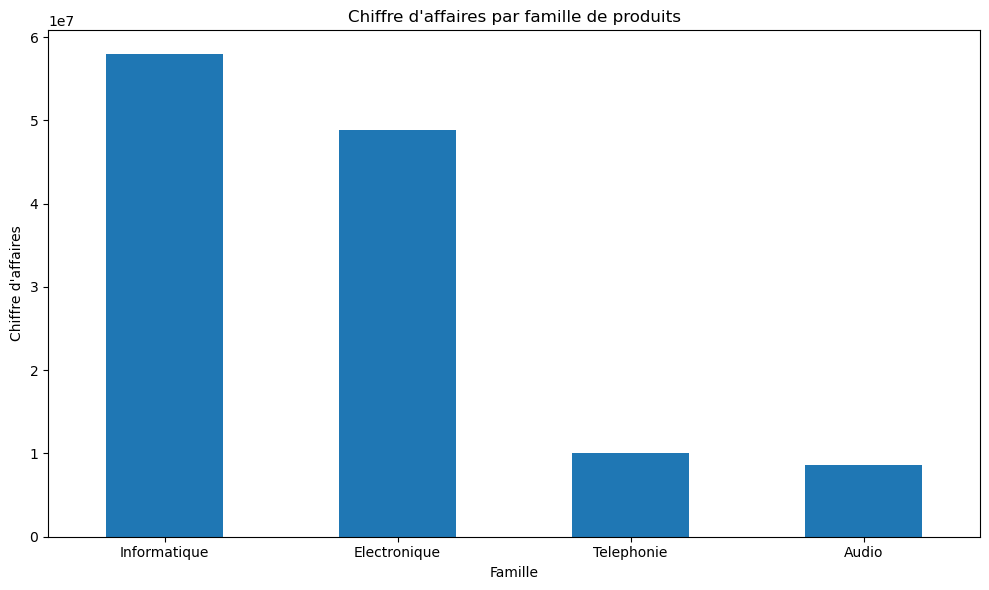

In [47]:
# Visualisation du CA par famille

plt.figure(figsize=(10, 6))

ca_famille.plot(kind="bar")

plt.title("Chiffre d'affaires par famille de produits")
plt.xlabel("Famille")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 🔎 Interprétation — CA par famille

Le graphique montre une forte concentration du chiffre d'affaires sur deux familles :

- **Informatique : 57,91 millions**, première contribution au chiffre d'affaires.
- **Électronique : 48,86 millions**, deuxième contribution.
- **Téléphonie : 10,11 millions**.
- **Audio : 8,59 millions**.

Les familles Informatique et Électronique représentent ensemble environ **85 % du chiffre d'affaires total**. L'activité commerciale est donc principalement portée par ces deux familles, tandis que la Téléphonie et l'Audio contribuent plus modestement au chiffre d'affaires.

Cette concentration constitue un premier élément important à prendre en compte dans l'analyse de la performance des produits.

In [17]:
# Chiffre d'affaires par ville

ca_ville = (
    df_ml.groupby("ville")["CA"]
    .sum()
    .sort_values(ascending=False)
)

print(ca_ville)

ville
Bamako     46040000
Abidjan    44920000
Conakry    33990000
Dakar        520000
Name: CA, dtype: int64


### 🔎 Interprétation — CA par ville

La répartition du chiffre d'affaires montre une forte concentration géographique :

- **Bamako : 46,04 millions**
- **Abidjan : 44,92 millions**
- **Conakry : 33,99 millions**
- **Dakar : 0,52 million**

Bamako et Abidjan génèrent à elles seules la majeure partie du chiffre d'affaires, tandis que Conakry contribue également de manière importante.

Dakar présente en revanche un chiffre d'affaires très faible par rapport aux autres villes. Cet écart devra être examiné plus précisément afin de déterminer s'il correspond à une différence réelle d'activité ou à une caractéristique particulière des données.

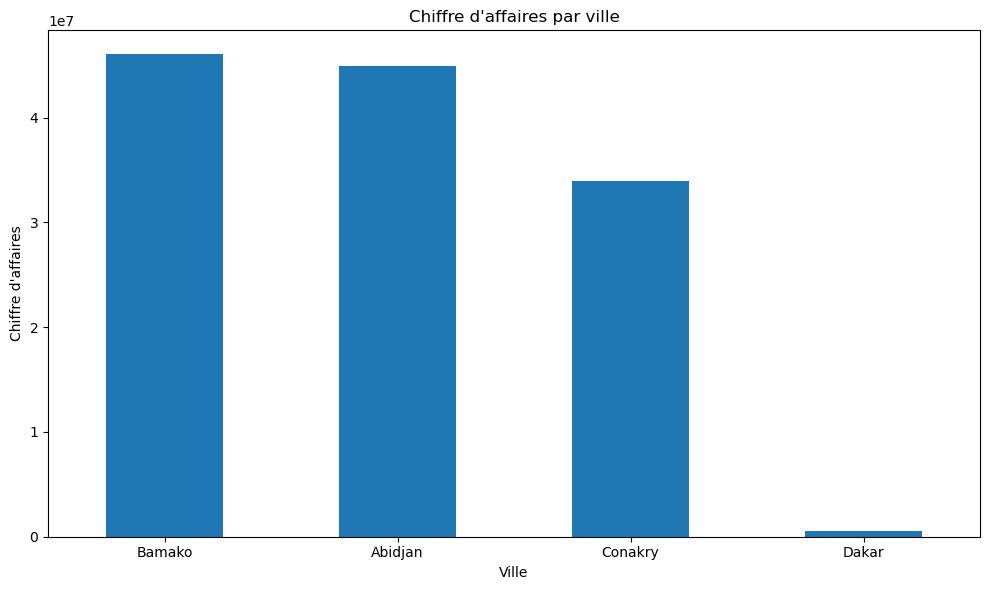

In [18]:
# Visualisation du CA par ville

plt.figure(figsize=(10, 6))

ca_ville.plot(kind="bar")

plt.title("Chiffre d'affaires par ville")
plt.xlabel("Ville")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# Analyse du volume d'activité par ville

analyse_ville = (
    df_ml.groupby("ville")
    .agg(
        Nombre_transactions=("transaction_id", "nunique"),
        Quantite_vendue=("quantite", "sum"),
        CA=("CA", "sum"),
        Marge=("Marge", "sum")
    )
    .sort_values("CA", ascending=False)
)

analyse_ville

,Nombre_transactions,Quantite_vendue,CA,Marge
ville,,,,
Bamako,38,151,46040000,16835000
Abidjan,49,171,44920000,16560000
Conakry,31,112,33990000,12610000
Dakar,2,4,520000,220000


### 🔎 Analyse du CA par ville

L'analyse du volume d'activité permet d'expliquer l'écart observé pour Dakar.

- **Abidjan** : 49 transactions et 171 unités vendues
- **Bamako** : 38 transactions et 151 unités vendues
- **Conakry** : 31 transactions et 112 unités vendues
- **Dakar** : 2 transactions et 4 unités vendues

Le faible chiffre d'affaires de Dakar s'explique donc principalement par un volume de transactions beaucoup plus faible dans les données étudiées.

Cette observation montre l'importance de compléter l'analyse du chiffre d'affaires par des indicateurs de volume afin d'éviter d'interpréter un CA faible sans examiner son contexte.

In [20]:
# Chiffre d'affaires par produit

ca_produit = (
    df_ml.groupby("designation")["CA"]
    .sum()
    .sort_values(ascending=False)
)

print(ca_produit)

designation
Ordinateur portable    30550000
Appareil photo         24940000
Televiseur LED         23920000
Disque SSD             13350000
Tablette                8500000
Smartphone              6600000
Enceinte Bluetooth      6270000
Imprimante              5510000
Montre connectee        3510000
Casque audio            2320000
Name: CA, dtype: int64


### 🔎 Interprétation — CA par produit

L'analyse du chiffre d'affaires par produit met en évidence une contribution différente selon les articles.

- **Ordinateur portable : 30,55 millions**
- **Appareil photo : 24,94 millions**
- **Televiseur LED : 23,92 millions**
- **Disque SSD : 13,35 millions**
- **Tablette : 8,50 millions**
- **Smartphone : 6,60 millions**
- **Enceinte Bluetooth : 6,27 millions**
- **Imprimante : 5,51 millions**
- **Montre connectee : 3,51 millions**
- **Casque audio : 2,32 millions**

Les trois premiers produits représentent une part importante du chiffre d'affaires total. L'ordinateur portable constitue le principal contributeur individuel au CA, tandis que plusieurs produits génèrent des montants plus modestes.

Cette analyse permet d'identifier les produits qui contribuent le plus au chiffre d'affaires et servira de base pour approfondir l'analyse des volumes et de la rentabilité.

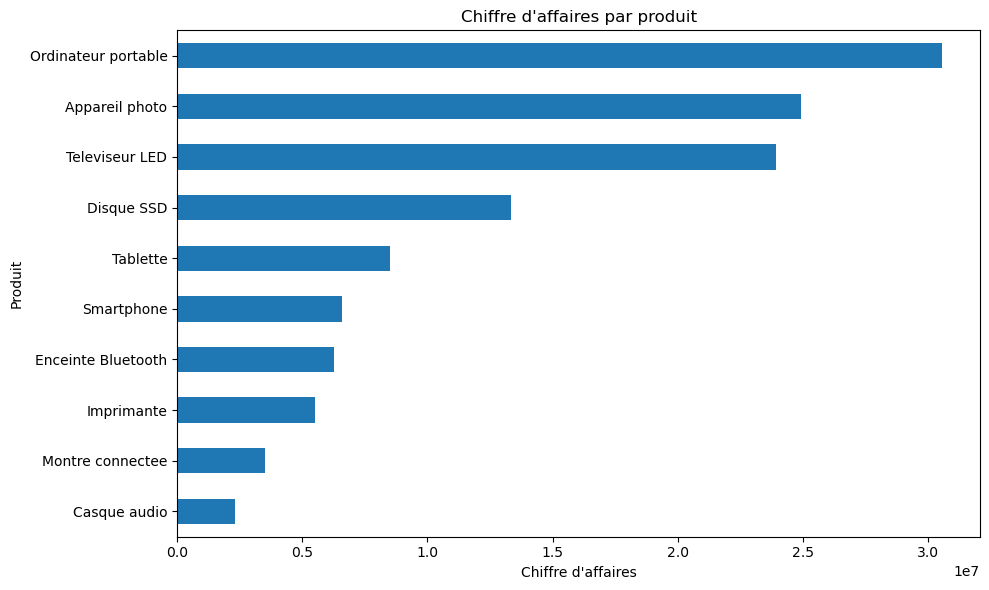

In [21]:
# Visualisation du CA par produit

plt.figure(figsize=(10, 6))

ca_produit.sort_values().plot(kind="barh")

plt.title("Chiffre d'affaires par produit")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Produit")

plt.tight_layout()
plt.show()

### 🔎 Interprétation — performance des produits

Le chiffre d'affaires est principalement porté par trois produits :

- **Ordinateur portable : 30,55 millions**
- **Appareil photo : 24,94 millions**
- **Televiseur LED : 23,92 millions**

À eux trois, ces produits génèrent environ **63 % du chiffre d'affaires total**. Le Disque SSD arrive ensuite avec **13,35 millions**, tandis que les autres produits présentent des contributions plus faibles.

Cette analyse montre que le chiffre d'affaires est concentré sur un nombre limité de produits. Il sera donc intéressant de comparer cette performance avec les **quantités vendues**, afin de distinguer l'effet du volume de ventes de celui du prix des produits.

In [22]:
# Chiffre d'affaires mensuel

ca_mensuel = (
    df_ml.groupby(
        df_ml["date_transaction"].dt.to_period("M")
    )["CA"]
    .sum()
)

print(ca_mensuel)

date_transaction
2023-01    2040000
2023-02    1380000
2023-03     300000
2023-04    3390000
2023-05    4570000
2023-06     390000
2023-07    2910000
2023-08    1660000
2023-09     970000
2023-10    7080000
2023-11     660000
2023-12    1750000
2024-01    5920000
2024-02    8140000
2024-03    3370000
2024-04     430000
2024-05    1480000
2024-06    2540000
2024-07    3390000
2024-08     300000
2024-09    3730000
2024-10    8460000
2024-11    5490000
2024-12    5030000
2025-01     960000
2025-02    6190000
2025-03    3360000
2025-04    4550000
2025-05    7950000
2025-06    6200000
2025-07     250000
2025-08    4050000
2025-09     150000
2025-10    6470000
2025-11    4540000
2025-12    5420000
Freq: M, Name: CA, dtype: int64


### 📅 Évolution mensuelle du chiffre d'affaires

L'analyse mensuelle permet d'observer l'évolution de l'activité commerciale dans le temps et d'identifier les périodes de forte ou de faible activité.

La série couvre la période de **janvier 2023 à décembre 2025**, soit trois années complètes.

Les montants mensuels présentent une forte variabilité, avec plusieurs pics de chiffre d'affaires et certains mois caractérisés par un niveau d'activité particulièrement faible.

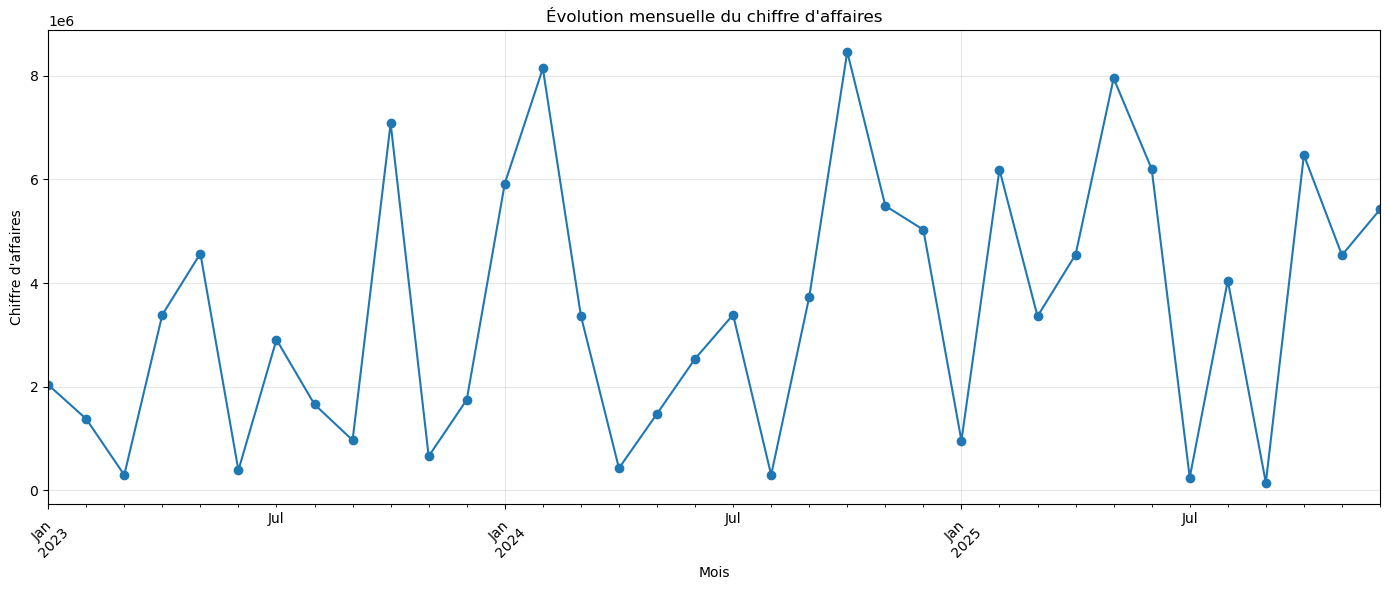

In [23]:
# Visualisation de l'évolution mensuelle du chiffre d'affaires

plt.figure(figsize=(14, 6))

ca_mensuel.plot(kind="line", marker="o")

plt.title("Évolution mensuelle du chiffre d'affaires")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 🔎 Interprétation — évolution mensuelle du CA

L'évolution mensuelle du chiffre d'affaires montre une forte variabilité de l'activité commerciale sur la période 2023-2025.

Plusieurs pics sont observés, notamment en **octobre 2023 (7,08 millions)**, **février 2024 (8,14 millions)**, **octobre 2024 (8,46 millions)** et **mai 2025 (7,95 millions)**.

À l'inverse, certains mois présentent un chiffre d'affaires particulièrement faible, comme **mars 2023 (0,30 million)**, **juin 2023 (0,39 million)**, **avril 2024 (0,43 million)** et **juillet 2025 (0,25 million)**.

Cette évolution montre que l'activité n'est pas stable d'un mois à l'autre. Une comparaison des performances annuelles permettra de déterminer comment le chiffre d'affaires global évolue entre 2023, 2024 et 2025.

In [24]:
# Chiffre d'affaires annuel

ca_annuel = (
    df_ml.groupby(
        df_ml["date_transaction"].dt.year
    )["CA"]
    .sum()
)

print("CA annuel :")
print(ca_annuel)

# Évolution annuelle en pourcentage
evolution_annuelle = ca_annuel.pct_change() * 100

print("\nÉvolution annuelle (%) :")
print(evolution_annuelle)

CA annuel :
date_transaction
2023    27100000
2024    48280000
2025    50090000
Name: CA, dtype: int64

Évolution annuelle (%) :
date_transaction
2023          NaN
2024    78.154982
2025     3.748964
Name: CA, dtype: float64


### 🔎 Interprétation — évolution annuelle du CA

Le chiffre d'affaires annuel progresse fortement entre 2023 et 2024 :

- **2023 : 27,10 millions**
- **2024 : 48,28 millions**, soit une progression de **78,15 %**
- **2025 : 50,09 millions**, soit une progression supplémentaire de **3,75 %**

L'année 2024 marque donc une forte augmentation du chiffre d'affaires par rapport à 2023. En 2025, le chiffre d'affaires continue de progresser, mais à un rythme beaucoup plus modéré.

Cette évolution montre une forte croissance entre 2023 et 2024, suivie d'une phase de progression plus stable en 2025.

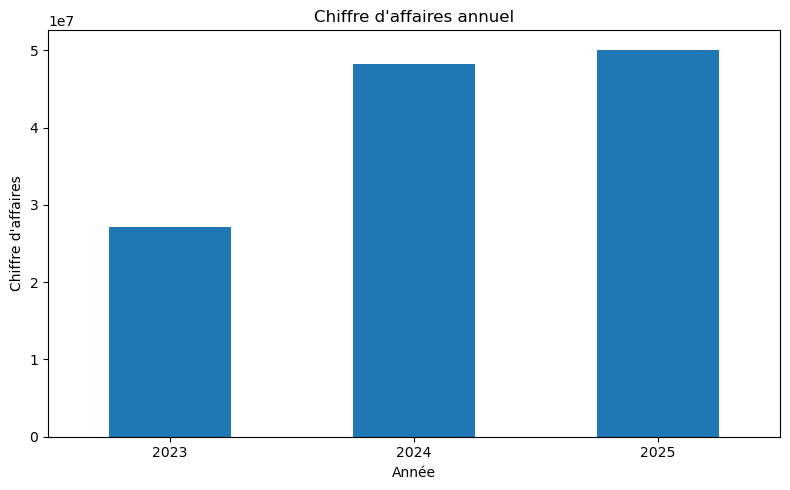

In [25]:
# Visualisation du chiffre d'affaires annuel

plt.figure(figsize=(8, 5))

ca_annuel.plot(kind="bar")

plt.title("Chiffre d'affaires annuel")
plt.xlabel("Année")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 🔎 Lecture du graphique annuel

Le graphique confirme la progression du chiffre d'affaires sur les trois années étudiées.

L'augmentation est particulièrement marquée entre **2023 et 2024**, tandis que l'écart entre **2024 et 2025** est beaucoup plus faible.

Cette évolution indique que la croissance observée sur la période est principalement concentrée entre 2023 et 2024. L'analyse de la marge permettra maintenant de vérifier si cette progression du chiffre d'affaires s'accompagne également d'une évolution de la rentabilité.

In [26]:
# Calcul du taux de marge global

taux_marge = (
    df_ml["Marge"].sum() / df_ml["CA"].sum()
) * 100

print("CA total :", df_ml["CA"].sum())
print("Marge totale :", df_ml["Marge"].sum())
print("Taux de marge :", round(taux_marge, 2), "%")

CA total : 125470000
Marge totale : 46225000
Taux de marge : 36.84 %


### 🔎 Interprétation — rentabilité globale

Sur l'ensemble des 120 transactions, le chiffre d'affaires atteint **125,47 millions** pour une marge totale de **46,225 millions**.

Le taux de marge global s'établit à **36,84 %**.

Cet indicateur permet de compléter l'analyse du chiffre d'affaires en intégrant la dimension de rentabilité. Deux produits ou familles peuvent générer des niveaux de chiffre d'affaires différents tout en présentant des marges différentes.

Il est donc pertinent d'analyser maintenant la marge par famille de produits afin d'identifier les catégories qui contribuent le plus à la rentabilité.

In [27]:
# Marge par famille de produits

marge_famille = (
    df_ml.groupby("famille")["Marge"]
    .sum()
    .sort_values(ascending=False)
)

print(marge_famille)

famille
Informatique    21580000
Electronique    16520000
Telephonie       4260000
Audio            3865000
Name: Marge, dtype: int64


### 🔎 Interprétation — marge par famille

La marge est principalement générée par les familles **Informatique** et **Électronique** :

- **Informatique : 21,58 millions**
- **Électronique : 16,52 millions**
- **Téléphonie : 4,26 millions**
- **Audio : 3,865 millions**

L'Informatique représente la contribution la plus importante à la marge totale, suivie de l'Électronique. Les deux familles concentrent ainsi l'essentiel de la rentabilité générée par les ventes.

Cette analyse confirme que les familles qui contribuent fortement au chiffre d'affaires jouent également un rôle important dans la marge. Nous allons maintenant comparer leur **taux de marge**, car un CA élevé ne signifie pas nécessairement une rentabilité proportionnellement élevée.

In [28]:
# Comparaison du CA, de la marge et du taux de marge par famille

analyse_famille = (
    df_ml.groupby("famille")
    .agg(
        CA=("CA", "sum"),
        Marge=("Marge", "sum")
    )
)

analyse_famille["Taux_marge"] = (
    analyse_famille["Marge"]
    / analyse_famille["CA"]
    * 100
)

analyse_famille = analyse_famille.sort_values(
    "CA",
    ascending=False
)

analyse_famille

,CA,Marge,Taux_marge
famille,,,
Informatique,57910000,21580000,37.264721
Electronique,48860000,16520000,33.810888
Telephonie,10110000,4260000,42.136499
Audio,8590000,3865000,44.994179


### 🔎 Interprétation — taux de marge par famille

L'analyse met en évidence des différences importantes de rentabilité entre les familles :

- **Audio : 44,99 %**
- **Téléphonie : 42,14 %**
- **Informatique : 37,26 %**
- **Électronique : 33,81 %**

L'Informatique génère le chiffre d'affaires et la marge les plus élevés en valeur absolue, mais son taux de marge est inférieur à celui de l'Audio et de la Téléphonie.

À l'inverse, l'Audio présente le taux de marge le plus élevé, mais son chiffre d'affaires reste nettement inférieur à celui de l'Informatique et de l'Électronique.

Cette comparaison montre l'importance de distinguer **volume d'activité, chiffre d'affaires et rentabilité** lors de l'analyse de la performance commerciale.

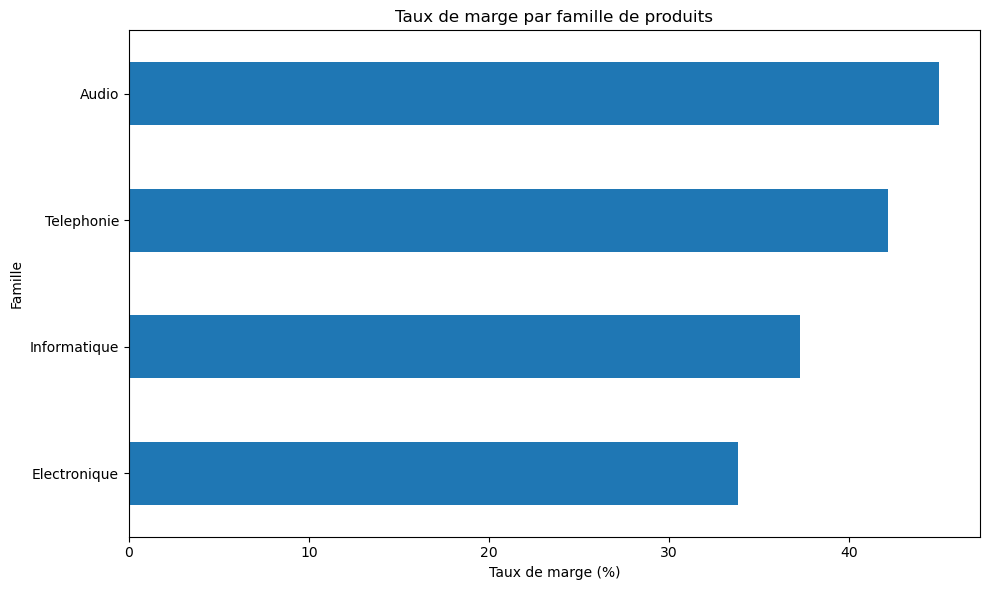

In [29]:
# Visualisation du taux de marge par famille

plt.figure(figsize=(10, 6))

analyse_famille["Taux_marge"].sort_values().plot(kind="barh")

plt.title("Taux de marge par famille de produits")
plt.xlabel("Taux de marge (%)")
plt.ylabel("Famille")

plt.tight_layout()
plt.show()

### 🔎 Interprétation — taux de marge

Le graphique met en évidence une différence de rentabilité entre les familles de produits.

L'**Audio** présente le taux de marge le plus élevé avec **44,99 %**, suivi de la **Téléphonie avec 42,14 %**. L'**Informatique** affiche un taux de marge de **37,26 %**, tandis que l'**Électronique** présente le taux le plus faible avec **33,81 %**.

Cette analyse complète l'étude du chiffre d'affaires : une famille peut générer un CA important sans avoir nécessairement le taux de marge le plus élevé.

L'analyse commerciale permet ainsi de distinguer trois dimensions complémentaires : **volume des ventes, chiffre d'affaires et rentabilité**.

## 4. 🤖 Machine Learning — Régression

L'objectif de cette partie est de construire des modèles capables de prédire le chiffre d'affaires d'une transaction à partir de plusieurs caractéristiques disponibles dans les données.

Deux modèles seront comparés :

- Régression linéaire
- Random Forest Regressor

Les performances seront évaluées avec trois indicateurs : MAE, RMSE et R².

In [30]:
# Définition des variables pour la régression

X = df_ml[
    ["quantite", "cout_unitaire", "prix_public", "Age"]
]

y = df_ml["CA"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

display(X.head())
display(y.head())

Dimensions de X : (120, 4)
Dimensions de y : (120,)


,quantite,cout_unitaire,prix_public,Age
0,3,280000,430000,36
1,5,90000,150000,37
2,4,70000,130000,30
3,2,280000,430000,36
4,2,90000,150000,41


0    1290000
1     750000
2     520000
3     860000
4     300000
Name: CA, dtype: int64

### 4.2 ✂️ Séparation des données

Les données sont séparées en deux ensembles :

- **80 % des données** pour entraîner les modèles ;
- **20 % des données** pour évaluer leurs performances sur des observations non utilisées pendant l'entraînement.

Un `random_state` de 42 est utilisé afin de garantir la reproductibilité des résultats.

In [31]:
from sklearn.model_selection import train_test_split

# Séparation des données en entraînement et test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (96, 4)
X_test  : (24, 4)
y_train : (96,)
y_test  : (24,)


### 4.3 📈 Régression linéaire

La régression linéaire constitue notre premier modèle de référence.

Elle cherche à établir une relation entre les variables explicatives (`quantite`, `cout_unitaire`, `prix_public`, `Age`) et le chiffre d'affaires.

Le modèle est entraîné sur les 96 observations d'entraînement, puis évalué sur les 24 observations de test.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Création et entraînement du modèle

modele_lineaire = LinearRegression()

modele_lineaire.fit(X_train, y_train)

# Prédictions sur les données de test

y_pred_lineaire = modele_lineaire.predict(X_test)

# Évaluation du modèle

mae_lineaire = mean_absolute_error(y_test, y_pred_lineaire)
rmse_lineaire = np.sqrt(mean_squared_error(y_test, y_pred_lineaire))
r2_lineaire = r2_score(y_test, y_pred_lineaire)

print("MAE :", mae_lineaire)
print("RMSE :", rmse_lineaire)
print("R² :", r2_lineaire)

MAE : 385888.85687201325
RMSE : 553446.0367955513
R² : 0.8226936448264678


### 🔎 Interprétation — Régression linéaire

Le modèle de régression linéaire obtient les performances suivantes :

- **MAE : 385 889**
- **RMSE : 553 446**
- **R² : 0,823**

Le coefficient de détermination **R² de 0,823** indique que le modèle explique environ **82,3 % de la variabilité du chiffre d'affaires** sur les données de test.

L'erreur absolue moyenne est d'environ **386 000** par transaction. Le modèle fournit donc une première estimation satisfaisante du chiffre d'affaires, mais certaines prédictions présentent encore des écarts importants.

Nous allons maintenant comparer ces résultats avec un modèle **Random Forest**, capable de capturer des relations non linéaires entre les variables.

### 4.4 🌳 Random Forest Regressor

Le deuxième modèle utilisé est le Random Forest Regressor.

Contrairement à la régression linéaire, ce modèle peut capturer des relations non linéaires entre les variables explicatives et le chiffre d'affaires.

Nous allons entraîner le modèle sur les mêmes données d'entraînement afin de pouvoir comparer directement ses performances avec celles de la régression linéaire.

In [33]:
from sklearn.ensemble import RandomForestRegressor

# Création du modèle
modele_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Entraînement
modele_rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = modele_rf.predict(X_test)

# Évaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)

MAE : 172570.83333333334
RMSE : 304015.96654890786
R² : 0.9464984302837179


### 🔎 Interprétation — Random Forest Regressor

Le modèle Random Forest obtient les performances suivantes :

- **MAE : 172 571**
- **RMSE : 304 016**
- **R² : 0,946**

Le modèle explique environ **94,6 % de la variabilité du chiffre d'affaires** sur les données de test.

Par rapport à la régression linéaire, le Random Forest présente des erreurs plus faibles et un R² plus élevé. Il semble donc mieux adapté aux relations présentes dans ces données.

Nous allons maintenant analyser l'importance des variables afin d'identifier les variables les plus utilisées par le modèle pour prédire le chiffre d'affaires.

### 4.5 🔍 Importance des variables

Le Random Forest permet d'estimer l'importance relative des variables utilisées pour effectuer les prédictions.

Cette analyse permet d'identifier les variables qui contribuent le plus aux prédictions du chiffre d'affaires.

In [34]:
importance = pd.DataFrame({
    "variable": X.columns,
    "importance": modele_rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(importance)

,variable,importance
0,quantite,0.381277
1,cout_unitaire,0.302385
2,prix_public,0.287520
3,Age,0.028818


### 🔎 Interprétation — importance des variables

L'analyse de l'importance des variables montre que les variables les plus utilisées par le Random Forest sont :

- **Quantité : 38,13 %**
- **Coût unitaire : 30,24 %**
- **Prix public : 28,75 %**
- **Âge : 2,88 %**

La quantité vendue constitue la variable ayant la plus forte importance dans le modèle, suivie du coût unitaire et du prix public.

L'âge présente une importance beaucoup plus faible dans les prédictions.

Ces résultats indiquent que les caractéristiques directement liées aux produits et aux volumes vendus jouent un rôle beaucoup plus important dans les prédictions du chiffre d'affaires que l'âge de l'acheteur.

⚠️ Cette importance ne signifie toutefois pas qu'une variable est une cause du chiffre d'affaires. Dans notre cas, le CA est directement calculé à partir de la quantité et du prix public, ce qui explique en partie l'importance élevée de ces variables.

<Figure size 1000x600 with 0 Axes>

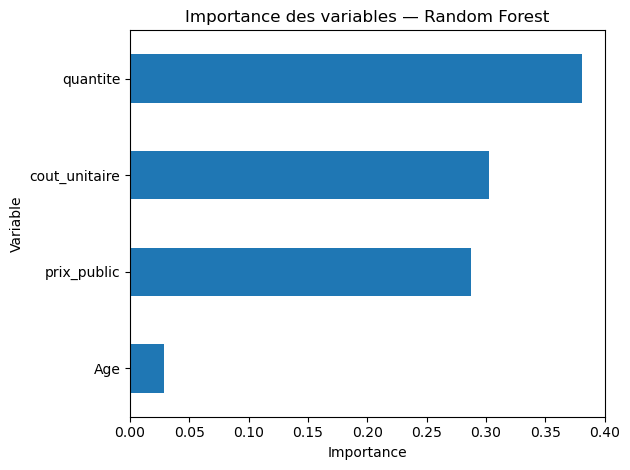

In [35]:
plt.figure(figsize=(10, 6))

importance.sort_values("importance").plot(
    x="variable",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### 🔎 Lecture du graphique

Le graphique confirme que la **quantité vendue** est la variable la plus importante pour les prédictions du Random Forest, suivie du **coût unitaire** et du **prix public**.

L'**âge de l'acheteur** présente une importance nettement plus faible.

Les variables directement liées à la transaction et au produit sont donc davantage utilisées par le modèle pour prédire le chiffre d'affaires.

Il faut cependant interpréter ces importances avec prudence : le chiffre d'affaires étant calculé à partir de la quantité et du prix public, leur forte importance est en partie liée à la construction même de la variable cible.

### 4.6 ⚖️ Comparaison des modèles

Nous comparons maintenant les performances de la régression linéaire et du Random Forest à partir des mêmes données de test.

Les critères utilisés sont :

- **MAE** : erreur absolue moyenne ;
- **RMSE** : racine de l'erreur quadratique moyenne ;
- **R²** : proportion de la variabilité du CA expliquée par le modèle.

In [36]:
comparaison_modeles = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Random Forest"
    ],
    "MAE": [
        mae_lineaire,
        mae_rf
    ],
    "RMSE": [
        rmse_lineaire,
        rmse_rf
    ],
    "R²": [
        r2_lineaire,
        r2_rf
    ]
})

display(comparaison_modeles)

,Modèle,MAE,RMSE,R²
0,Régression linéaire,385888.856872,553446.036796,0.822694
1,Random Forest,172570.833333,304015.966549,0.946498


### 🔎 Interprétation — comparaison des modèles

La comparaison montre une différence importante entre les deux modèles.

La **régression linéaire** obtient un R² de **0,823**, avec une MAE de **385 889** et une RMSE de **553 446**.

Le **Random Forest** obtient un R² de **0,946**, avec une MAE de **172 571** et une RMSE de **304 016**.

Le Random Forest présente donc des erreurs de prédiction plus faibles et explique une plus grande part de la variabilité du chiffre d'affaires sur les données de test.

Dans le cadre de ce jeu de données, le Random Forest fournit ainsi une meilleure performance prédictive que la régression linéaire.

⚠️ Cette comparaison doit toutefois être interprétée avec prudence, car le chiffre d'affaires est directement calculé à partir de la quantité et du prix public, deux variables utilisées comme prédicteurs.

## 5. 🤖 Machine Learning — Classification

L'objectif de cette partie est de construire un modèle capable de déterminer si une transaction correspond à une **vente élevée** ou à une **vente non élevée**.

Nous allons transformer le chiffre d'affaires en une variable binaire :

- `1` : vente élevée
- `0` : vente non élevée

Le seuil sera défini à partir de la **médiane du chiffre d'affaires**.

Deux modèles seront ensuite comparés :

- Régression logistique
- Random Forest Classifier

### 5.1 🎯 Création de la variable cible

Nous définissons comme vente élevée toute transaction dont le chiffre d'affaires est supérieur ou égal à la médiane du chiffre d'affaires.

In [37]:
# Calcul du seuil
seuil = df_ml["CA"].median()

# Création de la variable cible
df_ml["vente_elevee"] = (
    df_ml["CA"] >= seuil
).astype(int)

print("Seuil de vente élevée :", seuil)

print("\nRépartition des classes :")
print(df_ml["vente_elevee"].value_counts())

Seuil de vente élevée : 660000.0

Répartition des classes :
vente_elevee
1    62
0    58
Name: count, dtype: int64


### 🔎 Interprétation — variable cible

La médiane du chiffre d'affaires est de **660 000**.

La variable `vente_elevee` est donc répartie de la manière suivante :

- **62 transactions**, soit environ 51,7 %, sont classées comme ventes élevées.
- **58 transactions**, soit environ 48,3 %, sont classées comme ventes non élevées.

Les deux classes sont relativement équilibrées, ce qui permet de poursuivre l'entraînement des modèles de classification sans déséquilibre majeur entre les catégories.

### 5.2 ✂️ Préparation des données

Nous utilisons les mêmes variables explicatives que pour la régression :

- `quantite`
- `cout_unitaire`
- `prix_public`
- `Age`

La variable cible est maintenant `vente_elevee`.

Les données seront séparées en ensembles d'entraînement et de test. Une séparation stratifiée sera utilisée afin de conserver une proportion similaire des deux classes dans les deux ensembles.

In [38]:
from sklearn.model_selection import train_test_split

X_class = df_ml[
    ["quantite", "cout_unitaire", "prix_public", "Age"]
]

y_class = df_ml["vente_elevee"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("X_train :", X_train_class.shape)
print("X_test  :", X_test_class.shape)
print("y_train :", y_train_class.shape)
print("y_test  :", y_test_class.shape)

print("\nRépartition dans y_train :")
print(y_train_class.value_counts())

print("\nRépartition dans y_test :")
print(y_test_class.value_counts())

X_train : (96, 4)
X_test  : (24, 4)
y_train : (96,)
y_test  : (24,)

Répartition dans y_train :
vente_elevee
1    50
0    46
Name: count, dtype: int64

Répartition dans y_test :
vente_elevee
1    12
0    12
Name: count, dtype: int64


### 🔎 Interprétation — séparation des données

Les données ont été séparées en **96 observations d'entraînement** et **24 observations de test**.

Grâce à la stratification :

- l'ensemble d'entraînement contient **50 ventes élevées** et **46 ventes non élevées** ;
- l'ensemble de test contient **12 ventes élevées** et **12 ventes non élevées**.

La répartition des classes est donc équilibrée dans les données de test, ce qui permettra d'évaluer correctement les performances du modèle.

### 5.3 📈 Régression logistique

La régression logistique constitue notre premier modèle de classification.

Elle permet d'estimer la probabilité qu'une transaction appartienne à la classe `vente_elevee = 1` ou `vente_elevee = 0`.

Le modèle sera entraîné sur les 96 observations d'entraînement puis évalué sur les 24 observations de test.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Création du modèle
modele_logistique = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entraînement
modele_logistique.fit(
    X_train_class,
    y_train_class
)

# Prédictions
y_pred_logistique = modele_logistique.predict(
    X_test_class
)

# Évaluation
accuracy_logistique = accuracy_score(
    y_test_class,
    y_pred_logistique
)

precision_logistique = precision_score(
    y_test_class,
    y_pred_logistique
)

recall_logistique = recall_score(
    y_test_class,
    y_pred_logistique
)

f1_logistique = f1_score(
    y_test_class,
    y_pred_logistique
)

print("Accuracy :", accuracy_logistique)
print("Precision :", precision_logistique)
print("Recall :", recall_logistique)
print("F1-score :", f1_logistique)

Accuracy : 0.8333333333333334
Precision : 0.8333333333333334
Recall : 0.8333333333333334
F1-score : 0.8333333333333334


### 🔎 Interprétation — Régression logistique

La régression logistique obtient les résultats suivants :

- **Accuracy : 83,33 %**
- **Precision : 83,33 %**
- **Recall : 83,33 %**
- **F1-score : 83,33 %**

Le modèle classe correctement environ **83 % des transactions** de l'ensemble de test.

La précision et le rappel étant identiques, le modèle présente ici un comportement équilibré entre l'identification des ventes élevées et la limitation des classifications incorrectes.

Ces résultats constituent une première référence pour notre problème de classification. Nous allons maintenant les comparer avec ceux d'un **Random Forest Classifier**.

### 5.4 🌳 Random Forest Classifier

Nous allons maintenant utiliser un Random Forest Classifier pour déterminer si une transaction correspond à une vente élevée.

Comme pour la régression, ce modèle peut capturer des relations non linéaires entre les variables explicatives et la variable cible.

In [40]:
from sklearn.ensemble import RandomForestClassifier

# Création du modèle
modele_rf_class = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entraînement
modele_rf_class.fit(
    X_train_class,
    y_train_class
)

# Prédictions
y_pred_rf_class = modele_rf_class.predict(
    X_test_class
)

# Évaluation
accuracy_rf = accuracy_score(
    y_test_class,
    y_pred_rf_class
)

precision_rf = precision_score(
    y_test_class,
    y_pred_rf_class
)

recall_rf = recall_score(
    y_test_class,
    y_pred_rf_class
)

f1_rf = f1_score(
    y_test_class,
    y_pred_rf_class
)

print("Accuracy :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall :", recall_rf)
print("F1-score :", f1_rf)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-score : 1.0


### 🔎 Interprétation — Random Forest Classifier

Le Random Forest Classifier obtient les résultats suivants :

- **Accuracy : 100 %**
- **Precision : 100 %**
- **Recall : 100 %**
- **F1-score : 100 %**

Sur les 24 observations de test, le modèle a correctement classé toutes les transactions.

Ce résultat est toutefois à interpréter avec prudence. La variable `vente_elevee` a été construite à partir du chiffre d'affaires, lui-même calculé à partir de la quantité et du prix public. Ces mêmes variables sont utilisées comme variables explicatives du modèle.

La performance parfaite observée est donc en partie liée à cette relation directe entre les variables explicatives et la variable cible. Elle ne doit pas être interprétée comme une garantie de performance sur de nouvelles données.

### 5.5 ⚖️ Comparaison des modèles de classification

Nous comparons maintenant les performances de la régression logistique et du Random Forest Classifier à partir des mêmes données de test.

Les critères utilisés sont :

- **Accuracy** : proportion de prédictions correctes ;
- **Precision** : proportion des ventes prédites comme élevées qui le sont réellement ;
- **Recall** : proportion des ventes élevées correctement identifiées ;
- **F1-score** : compromis entre précision et rappel.

In [41]:
comparaison_classification = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistique,
        accuracy_rf
    ],
    "Precision": [
        precision_logistique,
        precision_rf
    ],
    "Recall": [
        recall_logistique,
        recall_rf
    ],
    "F1-score": [
        f1_logistique,
        f1_rf
    ]
})

display(comparaison_classification)

,Modèle,Accuracy,Precision,Recall,F1-score
0,Régression logistique,0.833333,0.833333,0.833333,0.833333
1,Random Forest,1.000000,1.000000,1.000000,1.000000


### 🔎 Interprétation — comparaison des modèles de classification

La régression logistique obtient une performance de **83,33 %** sur les quatre métriques évaluées.

Le Random Forest obtient **100 %** sur l'Accuracy, la Precision, le Recall et le F1-score sur l'échantillon de test.

Le Random Forest réalise donc davantage de classifications correctes sur cet échantillon de test.

Cependant, cette performance parfaite doit être interprétée avec prudence : la variable `vente_elevee` est construite à partir du CA, qui dépend directement de la quantité et du prix public utilisés comme variables explicatives. Le résultat peut donc refléter cette relation mathématique directe plutôt qu'une capacité générale de prédiction.

Cette limite devra être mentionnée dans la conclusion du projet.

### 5.6 🔲 Matrice de confusion

La matrice de confusion permet de détailler les prédictions du modèle en distinguant :

- les ventes élevées correctement identifiées ;
- les ventes non élevées correctement identifiées ;
- les erreurs de classification.

Matrice de confusion :
[[12  0]
 [ 0 12]]


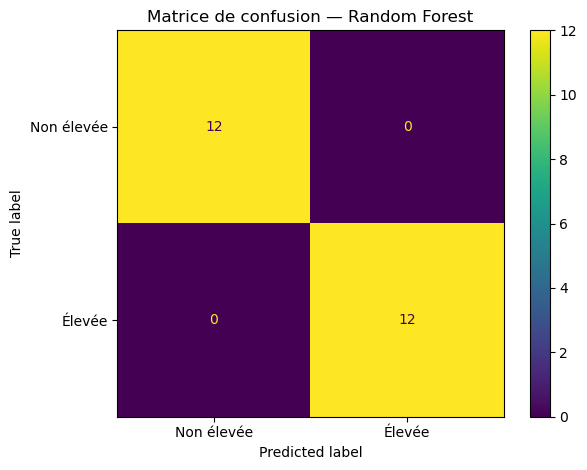

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrice = confusion_matrix(
    y_test_class,
    y_pred_rf_class
)

print("Matrice de confusion :")
print(matrice)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matrice,
    display_labels=["Non élevée", "Élevée"]
)

disp.plot()
plt.title("Matrice de confusion — Random Forest")
plt.tight_layout()
plt.show()

### 🔎 Interprétation — matrice de confusion

La matrice de confusion montre que le Random Forest a correctement classé les **24 observations de test** :

- **12 ventes non élevées** ont été correctement identifiées ;
- **12 ventes élevées** ont été correctement identifiées ;
- aucune vente non élevée n'a été classée comme élevée ;
- aucune vente élevée n'a été classée comme non élevée.

Le modèle ne présente donc aucune erreur de classification sur cet échantillon de test.

Ce résultat confirme les scores de **100 %** obtenus pour l'Accuracy, la Precision, le Recall et le F1-score.

⚠️ Comme indiqué précédemment, cette performance parfaite doit être interprétée avec prudence, car la variable cible `vente_elevee` est directement dérivée du chiffre d'affaires, lui-même calculé à partir de variables utilisées comme prédicteurs.

### 5.7 🔍 Importance des variables

Le Random Forest Classifier permet également d'identifier l'importance relative des variables utilisées pour effectuer les classifications.

Cette analyse permettra de déterminer quelles caractéristiques contribuent le plus à distinguer les ventes élevées des ventes non élevées.

In [43]:
importance_class = pd.DataFrame({
    "variable": X_class.columns,
    "importance": modele_rf_class.feature_importances_
})

importance_class = importance_class.sort_values(
    "importance",
    ascending=False
)

display(importance_class)

,variable,importance
0,quantite,0.595682
1,cout_unitaire,0.175445
2,prix_public,0.156050
3,Age,0.072823


### 🔎 Interprétation — importance des variables

L'analyse montre que la **quantité vendue** est de loin la variable la plus importante pour la classification des transactions, avec une importance de **59,57 %**.

Elle est suivie par :

- **Coût unitaire : 17,54 %**
- **Prix public : 15,61 %**
- **Âge : 7,28 %**

La quantité vendue joue donc un rôle particulièrement important dans la distinction entre les ventes élevées et les ventes non élevées.

Cependant, cette importance doit être interprétée avec prudence : la variable `vente_elevee` a été construite à partir du CA, lui-même calculé à partir de la quantité et du prix public. Il existe donc une relation directe entre certaines variables explicatives et la cible.

<Figure size 1000x600 with 0 Axes>

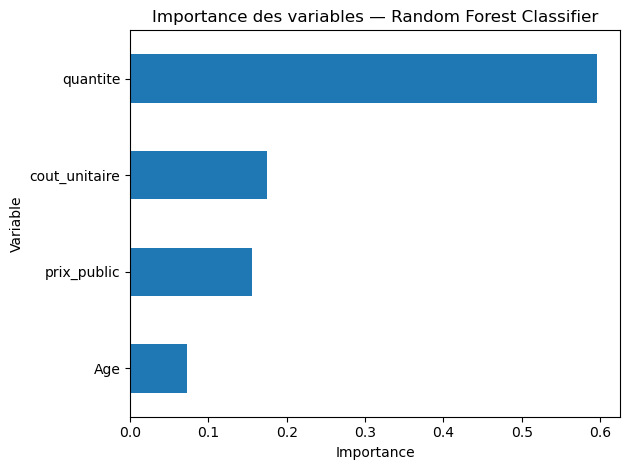

In [44]:
plt.figure(figsize=(10, 6))

importance_class.sort_values("importance").plot(
    x="variable",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Importance des variables — Random Forest Classifier")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### 🔎 Lecture du graphique

Le graphique confirme la forte importance de la variable **quantité**, qui représente environ **59,57 %** de l'importance totale du modèle.

Le **coût unitaire** et le **prix public** présentent des importances intermédiaires, respectivement de **17,54 %** et **15,61 %**. L'**âge** présente une importance plus faible, avec **7,28 %**.

La classification des ventes est donc principalement associée aux variables directement liées à la transaction et au produit.

Comme pour le modèle de régression, ces résultats doivent être interprétés avec prudence puisque la variable cible `vente_elevee` est construite à partir du chiffre d'affaires, lui-même dépendant de la quantité et du prix public.

## 6. 📊 Évaluation et synthèse des modèles

Cette section rassemble les résultats obtenus avec les différents modèles de Machine Learning.

L'objectif est de comparer leurs performances et de mettre en évidence les principaux enseignements du projet.

### 6.1 📈 Synthèse — régression

Les deux modèles de régression ont été évalués sur le même ensemble de test de 24 observations.

Le Random Forest obtient des erreurs de prédiction plus faibles et un R² supérieur à celui de la régression linéaire.

In [45]:
# Arrondir les résultats pour une présentation plus lisible

comparaison_regression = comparaison_modeles.copy()

comparaison_regression["MAE"] = comparaison_regression["MAE"].round(0)
comparaison_regression["RMSE"] = comparaison_regression["RMSE"].round(0)
comparaison_regression["R²"] = comparaison_regression["R²"].round(3)

display(comparaison_regression)

,Modèle,MAE,RMSE,R²
0,Régression linéaire,385889.0,553446.0,0.823
1,Random Forest,172571.0,304016.0,0.946


### 🔎 Interprétation — modèles de régression

La comparaison montre que le Random Forest obtient de meilleures performances que la régression linéaire sur l'ensemble de test.

La MAE passe de **385 889** à **172 571**, tandis que la RMSE passe de **553 446** à **304 016**.

Le R² progresse également de **0,823** à **0,946**, ce qui indique que le Random Forest explique une plus grande partie de la variabilité du chiffre d'affaires sur les données de test.

Ces résultats montrent que le Random Forest capture mieux les relations présentes dans ce jeu de données. Ils doivent toutefois être interprétés avec prudence puisque le CA est directement calculé à partir de certaines variables utilisées comme prédicteurs.

### 6.2 🤖 Synthèse — classification

Les deux modèles de classification ont été évalués sur les mêmes 24 observations de test.

La régression logistique obtient une performance de 83,33 % sur l'ensemble des métriques, tandis que le Random Forest obtient 100 % sur cet échantillon.

Ces résultats doivent toutefois être interprétés avec prudence, car la variable `vente_elevee` est construite à partir du chiffre d'affaires, lui-même calculé à partir de la quantité et du prix public utilisés comme variables explicatives.

In [46]:
comparaison_classification_arrondie = comparaison_classification.copy()

for colonne in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]:
    comparaison_classification_arrondie[colonne] = (
        comparaison_classification_arrondie[colonne] * 100
    ).round(2)

display(comparaison_classification_arrondie)

,Modèle,Accuracy,Precision,Recall,F1-score
0,Régression logistique,83.33,83.33,83.33,83.33
1,Random Forest,100.00,100.00,100.00,100.00


### 🔎 Interprétation — modèles de classification

La régression logistique obtient **83,33 %** sur l'Accuracy, la Precision, le Recall et le F1-score.

Le Random Forest obtient **100 %** sur les quatre métriques pour les 24 observations de test.

Ces résultats montrent que le Random Forest a correctement classé toutes les observations de test dans notre expérience.

Cependant, cette performance parfaite doit être interprétée avec prudence. La variable `vente_elevee` a été construite à partir du chiffre d'affaires, qui dépend directement de la `quantite` et du `prix_public`, deux variables utilisées comme prédicteurs.

Les performances obtenues ne doivent donc pas être considérées comme une garantie de performance sur de nouvelles données. Cette limite constitue un point important à mentionner dans la conclusion du projet.

## 7. 🧠 Interprétation globale des résultats

Cette section synthétise les principaux enseignements obtenus au cours de l'analyse des ventes et des modèles de Machine Learning.

L'objectif est de relier les résultats commerciaux aux résultats prédictifs afin d'obtenir une vision globale de la performance du jeu de données.

### 7.1 📊 Principaux enseignements commerciaux

L'analyse des ventes montre que le chiffre d'affaires total atteint **125,47 millions**, pour **120 transactions** et **438 unités vendues**.

Les familles **Informatique** et **Électronique** représentent la majeure partie du chiffre d'affaires, avec respectivement **57,91 millions** et **48,86 millions**.

L'analyse géographique montre que **Bamako, Abidjan et Conakry** concentrent l'essentiel de l'activité, tandis que Dakar présente un volume de transactions beaucoup plus faible.

Enfin, la marge totale atteint **46,225 millions**, soit un taux de marge global de **36,84 %**. Les taux de marge varient selon les familles, ce qui montre l'importance de distinguer chiffre d'affaires et rentabilité.

### 7.2 🤖 Principaux enseignements du Machine Learning

Pour la prédiction du chiffre d'affaires, le Random Forest obtient un **R² de 0,946**, contre **0,823** pour la régression linéaire, avec des erreurs de prédiction également plus faibles.

Pour la classification des ventes, la régression logistique obtient **83,33 %** sur les principales métriques, tandis que le Random Forest atteint **100 %** sur l'échantillon de test.

La quantité vendue apparaît comme une variable particulièrement importante dans les deux modèles de Random Forest.

Ces résultats doivent toutefois être interprétés avec prudence, car les variables `quantite` et `prix_public` interviennent directement dans le calcul du chiffre d'affaires et donc dans la construction de la variable `vente_elevee`.


### 7.3 ⚠️ Limites de l'analyse

Plusieurs limites doivent être prises en compte lors de l'interprétation des résultats.

- Le jeu de données contient seulement **120 transactions**, ce qui constitue un volume relativement limité pour généraliser les résultats à une population plus large.
- Le chiffre d'affaires est calculé directement à partir de la **quantité** et du **prix public**, qui sont également utilisés comme variables explicatives dans le modèle de régression.
- La variable `vente_elevee` est construite à partir du chiffre d'affaires. Les performances très élevées du modèle de classification doivent donc être interprétées avec prudence.
- Les données disponibles ne prennent pas en compte d'autres facteurs pouvant influencer les ventes, comme les promotions, la saisonnalité détaillée, les stocks, les campagnes marketing ou les caractéristiques des produits plus approfondies.
- Les performances obtenues sont mesurées sur un seul découpage entraînement/test. Une validation croisée pourrait permettre d'obtenir une évaluation plus robuste des modèles.

Ces limites montrent que les modèles constituent principalement une **preuve de concept** sur ce jeu de données. Une application réelle nécessiterait davantage de données et des variables explicatives supplémentaires.

### 7.4 🚀 Pistes d'amélioration

Pour améliorer la robustesse et la capacité de généralisation des modèles, plusieurs pistes peuvent être envisagées :

- Augmenter le volume de données disponibles en intégrant davantage de transactions.
- Ajouter des variables explicatives telles que les promotions, les remises, les stocks, les campagnes marketing et les périodes commerciales.
- Utiliser une **validation croisée** afin d'obtenir une évaluation plus robuste des performances.
- Tester différents hyperparamètres du Random Forest afin d'optimiser ses performances.
- Éviter d'utiliser directement des variables qui interviennent dans la construction de la variable cible lorsque l'objectif est d'évaluer la capacité réelle de généralisation du modèle.
- Tester d'autres algorithmes de Machine Learning et comparer leurs performances.

Ces améliorations permettraient de construire des modèles plus robustes et plus proches d'un contexte réel d'utilisation.

## 8. 🎯 Conclusion

Cette analyse a permis d'étudier les performances commerciales à partir de **120 transactions**, **10 articles** et **20 acheteurs**.

L'analyse exploratoire a permis d'identifier les principaux contributeurs au chiffre d'affaires, notamment les familles **Informatique** et **Électronique**, ainsi que les différences de performance entre les villes, les produits et les périodes.

La partie Machine Learning a permis de comparer plusieurs modèles de régression et de classification. Pour la prédiction du chiffre d'affaires, le **Random Forest Regressor** a obtenu un R² de **0,946** sur les données de test, contre **0,823** pour la régression linéaire. Pour la classification des ventes élevées, le Random Forest a obtenu **100 %** sur les métriques évaluées sur l'échantillon de test.

Ces résultats montrent l'intérêt du Machine Learning pour compléter une analyse commerciale traditionnelle. Ils doivent néanmoins être interprétés avec prudence en raison de la taille limitée du jeu de données et de la relation directe entre certaines variables explicatives et les variables cibles.

Ce projet constitue ainsi une démonstration complète d'un processus d'analyse de données allant de la **préparation des données et de l'analyse exploratoire jusqu'à la modélisation et l'évaluation de modèles de Machine Learning**.

## 📌 Résumé exécutif

### 🎯 Contexte et objectif

Cette analyse porte sur les ventes réalisées à partir de 120 transactions, 10 articles et 20 acheteurs. L’objectif est d’analyser la performance commerciale, d’identifier les principaux facteurs associés au chiffre d’affaires et d’explorer l’utilisation du Machine Learning pour la prédiction et la classification des ventes.

### 📊 Principaux résultats commerciaux

* Le **chiffre d’affaires total** s’élève à **125,47 M**.
* **438 unités** ont été vendues à travers **120 transactions**.
* Le **montant total de la marge** atteint **46,225 M**, soit un **taux de marge global de 36,84 %**.
* Les familles **Informatique** et **Électronique** représentent les principales contributions au chiffre d’affaires.
* L’activité commerciale est principalement concentrée dans certaines villes, notamment **Bamako, Abidjan et Conakry**.

### 🤖 Résultats Machine Learning

Deux approches de régression ont été testées pour prédire le chiffre d’affaires :

* **Régression linéaire : R² = 0,823**
* **Random Forest Regressor : R² = 0,946**

Pour la classification des ventes élevées, les modèles Logistic Regression et Random Forest ont également été testés. Le Random Forest obtient **100 % sur les métriques évaluées**, tandis que la régression logistique obtient **83,33 %**.

### ⚠️ Limites de l'analyse

Les performances des modèles doivent toutefois être interprétées avec prudence. Le chiffre d’affaires est directement construit à partir de variables telles que la quantité et le prix public, qui sont également utilisées comme variables explicatives dans certains modèles. Cette relation directe peut entraîner une **fuite d'information (data leakage)** et surestimer les performances prédictives.

### 💡 Valeur de l'analyse

Cette étude permet de combiner **analyse commerciale, visualisation des données et Machine Learning** afin de mieux comprendre les ventes et d'identifier des pistes d'amélioration pour de futures analyses prédictives.


## Méthodologie du projet

Le projet suit une démarche complète d'analyse de données et de Machine Learning :

1. **Collecte et compréhension des données**
   - Importation des fichiers de transactions, articles et acheteurs.
   - Exploration de leur structure et de leurs variables.

2. **Nettoyage et préparation**
   - Vérification des valeurs manquantes et des doublons.
   - Contrôle des identifiants et de l'intégrité des données.
   - Conversion des variables de dates.
   - Fusion des différentes sources de données.

3. **Analyse exploratoire**
   - Analyse du chiffre d'affaires, des quantités vendues et de la marge.
   - Analyse des performances par famille, produit et ville.
   - Étude de l'évolution du chiffre d'affaires dans le temps.
   - Création de visualisations pour faciliter l'interprétation.

4. **Analyse business**
   - Identification des principales contributions au chiffre d'affaires.
   - Analyse des écarts de performance entre les différentes zones et familles.
   - Formulation d'insights et de recommandations.

5. **Machine Learning**
   - Mise en place de modèles de régression pour le chiffre d'affaires.
   - Mise en place de modèles de classification pour identifier les ventes élevées.
   - Comparaison et évaluation des performances des modèles.

6. **Interprétation et synthèse**
   - Analyse des résultats obtenus.
   - Identification des limites du projet.
   - Formulation de perspectives d'amélioration.

## 🔎 Insights business

### 1. Performance commerciale

Le chiffre d'affaires total atteint **125,47 M** pour **120 transactions**, avec **438 unités vendues**. La marge totale s'élève à **46,225 M**, correspondant à un taux de marge global de **36,84 %**.

### 2. Contribution des familles de produits

Les familles **Informatique** et **Électronique** représentent les principales contributions au chiffre d'affaires. Cette concentration indique que la performance commerciale dépend fortement de ces deux catégories.

### 3. Répartition géographique

L'analyse géographique montre une activité particulièrement importante à **Bamako, Abidjan et Conakry**, tandis que **Dakar présente un volume de transactions plus faible**. Cette différence peut constituer un axe d'analyse pour comprendre les écarts de performance entre les différentes zones.

### 4. Facteurs associés aux ventes

Les modèles de Machine Learning montrent que certaines variables commerciales, notamment la **quantité** et les variables liées aux prix, jouent un rôle important dans la prédiction du chiffre d'affaires et dans la classification des ventes élevées.

### 5. Point de vigilance sur le Machine Learning

Les résultats élevés obtenus par les modèles doivent être interprétés avec prudence. Le chiffre d'affaires étant directement calculé à partir de la quantité et du prix public, leur utilisation comme variables explicatives crée une relation directe avec la cible. Les performances obtenues constituent donc principalement une **preuve de concept** plutôt qu'une mesure définitive de la capacité prédictive sur de nouvelles données.


## 💡 Recommandations business

À partir des résultats obtenus, plusieurs pistes d'action peuvent être proposées :

### 1. Renforcer le suivi des familles les plus performantes

Les familles **Informatique** et **Électronique** génèrent les principales contributions au chiffre d'affaires. Il serait pertinent de suivre régulièrement leurs ventes, leurs marges et leur évolution afin d'identifier les produits présentant le meilleur potentiel commercial.

### 2. Analyser les écarts de performance entre les villes

Les différences observées entre les zones géographiques peuvent être étudiées plus en détail afin d'identifier les facteurs expliquant les variations de ventes et de déterminer où des actions commerciales pourraient être envisagées.

### 3. Suivre simultanément chiffre d'affaires et marge

Le chiffre d'affaires ne suffit pas à mesurer la performance commerciale. Le suivi conjoint du **CA**, de la **marge** et du **taux de marge** permettrait de mieux identifier les ventes réellement rentables.

### 4. Améliorer progressivement les modèles prédictifs

Pour obtenir des modèles plus représentatifs d'un contexte réel, il serait nécessaire d'utiliser davantage de données historiques et de construire les variables explicatives de manière à éviter toute fuite d'information entre les variables et la cible.

### 5. Développer l'analyse prédictive

Une prochaine étape pourrait consister à prédire le chiffre d'affaires sur de nouvelles périodes ou à identifier à l'avance les transactions susceptibles de générer un niveau de vente élevé, avec des données suffisamment riches pour permettre une évaluation fiable.
